# Plane-mirror ray tracing with Optiland + xrt

This notebook combines two complementary models:

- **Optiland** supplies a sequential 3-D geometric reflection model and an intensity coating.
- **xrt/raycing** supplies a Monte-Carlo source, a finite plane mirror, a detector screen, polarization-aware weights, and (for X-rays) tabulated material reflectivity.
- Closed-form reflection and energy-balance checks make errors in angles or units easy to spot.

Edit only the `MirrorConfig` cell for the main study. Lengths are in mm unless stated otherwise. Optiland wavelengths are converted to micrometres; xrt photon energies are in eV. The default is an 8.05 keV Au mirror because xrt's tabulated optical constants are intended for X-ray/EUV energies. For visible light, select `reflectance_model='constant'`.

## 0. Installation

Run this once in the intended Jupyter kernel, then restart the kernel.

In [1]:
# %pip install -U optiland xrt numpy matplotlib pandas ipywidgets
# After installation: Kernel -> Restart, then Run All.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optiland import optic
from optiland.coatings import BaseCoating

import xrt.backends.raycing as raycing
import xrt.backends.raycing.sources as rsources
import xrt.backends.raycing.oes as roes
import xrt.backends.raycing.screens as rscreens
import xrt.backends.raycing.materials as rmats

plt.rcParams.update({'figure.figsize': (9, 5.5), 'axes.grid': True, 'font.size': 11})
np.random.seed(7)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

for package in ('optiland', 'xrt', 'numpy', 'matplotlib'):
    try:
        print(f'{package:10s} {metadata.version(package)}')
    except metadata.PackageNotFoundError:
        print(f'{package:10s} version unavailable')

optiland   0.6.1
xrt        1.6.2
numpy      1.26.4
matplotlib 3.9.2


## 1. Customizable system parameters

`grazing_angle_deg` is measured from the mirror surface in the xrt model. `optiland_mirror_tilt_deg` is measured as a rotation of the plane normal about the x axis; 45 degrees turns a +z beam into +y.

In [2]:
@dataclass(frozen=True)
class MirrorConfig:
    # Spectrum and polarization
    wavelength_nm: float = 0.15406       # ~Cu K-alpha / 8.05 keV
    polarization: str = 'horizontal'     # xrt: horizontal, vertical, +45, ...

    # Source and finite mirror geometry
    n_rays: int = 20_000
    source_to_mirror_mm: float = 1000.0
    mirror_to_screen_mm: float = 800.0
    source_width_mm: float = 0.40
    source_height_mm: float = 0.20
    divergence_x_mrad: float = 0.10
    divergence_z_mrad: float = 0.05
    mirror_half_width_mm: float = 12.0
    mirror_half_length_mm: float = 80.0
    grazing_angle_deg: float = 0.50

    # Material model. Use 'constant' for visible/IR mirrors.
    reflectance_model: str = 'xrt_material'  # 'xrt_material' or 'constant'
    mirror_formula: str = 'Au'
    mirror_density_g_cm3: float = 19.32
    constant_reflectance: float = 0.90
    constant_absorptance: float = 0.10

    # Optiland 3-D preview uses a convenient fold-mirror geometry.
    optiland_mirror_tilt_deg: float = 45.0
    optiland_aperture_diameter_mm: float = 10.0
    save_figures: bool = True

CFG = MirrorConfig()
HC_EV_NM = 1239.8419843320026
ENERGY_EV = HC_EV_NM / CFG.wavelength_nm

assert CFG.wavelength_nm > 0 and CFG.n_rays > 0
assert 0 < CFG.grazing_angle_deg < 90
assert CFG.reflectance_model in {'xrt_material', 'constant'}
assert 0 <= CFG.constant_reflectance <= 1
assert 0 <= CFG.constant_absorptance <= 1
assert CFG.constant_reflectance + CFG.constant_absorptance <= 1 + 1e-12

print(f'Photon energy = {ENERGY_EV:.3f} eV ({ENERGY_EV/1000:.4f} keV)')
print(f'Expected beam deflection = {2*CFG.grazing_angle_deg:.3f} deg')

Photon energy = 8047.786 eV (8.0478 keV)
Expected beam deflection = 1.000 deg


## 2. Optiland plane mirror with a user-defined power coating

The coating multiplies ray intensity on reflection. The geometric trajectory follows the law of reflection; the unreflected fraction is reported separately as absorbed or transmitted power.

In [3]:
class PowerBudgetCoating(BaseCoating):
    def __init__(self, reflectance: float, transmittance: float = 0.0):
        self.R = float(reflectance)
        self.T = float(transmittance)

    def reflect(self, rays, nx, ny, nz):
        rays.i *= self.R
        return rays

    def transmit(self, rays, nx, ny, nz):
        rays.i *= self.T
        return rays

def build_optiland_plane_mirror(cfg: MirrorConfig, reflectance: float):
    alpha = np.deg2rad(cfg.optiland_mirror_tilt_deg)
    L1 = cfg.source_to_mirror_mm
    L2 = cfg.mirror_to_screen_mm
    # Reflection of d=(0,0,1) by a plane whose local normal is rotated by alpha.
    d_out = np.array([0.0, np.sin(2*alpha), -np.cos(2*alpha)])
    screen = np.array([0.0, 0.0, L1]) + L2*d_out
    transmittance = max(0.0, 1.0 - reflectance - cfg.constant_absorptance)
    coating = PowerBudgetCoating(reflectance, transmittance)

    system = optic.Optic(name='Finite plane fold mirror')
    system.surfaces.add(index=0, radius=np.inf, z=-np.inf)
    system.surfaces.add(index=1, radius=np.inf, z=0.0)
    system.surfaces.add(
        index=2, radius=np.inf, z=L1, rx=alpha, material='mirror',
        is_stop=True, coating=coating
    )
    system.surfaces.add(
        index=3, radius=np.inf, x=screen[0], y=screen[1], z=screen[2],
        rx=2*alpha
    )
    system.set_aperture(aperture_type='EPD', value=cfg.optiland_aperture_diameter_mm)
    system.fields.set_type(field_type='angle')
    system.fields.add(y=0.0)
    system.wavelengths.add(value=cfg.wavelength_nm/1000.0, is_primary=True)
    return system, d_out, screen

# A provisional constant R is used for the Optiland preview; the xrt material
# value calculated below can be substituted by rerunning this cell.
optiland_R = CFG.constant_reflectance
optiland_system, expected_direction, optiland_screen = build_optiland_plane_mirror(CFG, optiland_R)
print('Expected outgoing unit vector:', expected_direction)
print('Optiland detector centre [x,y,z] mm:', optiland_screen)
optiland_system.info()

Expected outgoing unit vector: [ 0.000000e+00  1.000000e+00 -6.123234e-17]
Optiland detector centre [x,y,z] mm: [   0.  800. 1000.]
╒════╤═══════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │           │      inf │         inf │ Air        │       0 │               5 │
│  1 │ Planar        │           │      inf │        1000 │ Air        │       0 │               5 │
│  2 │ Stop - Planar │           │      inf │           0 │ Mirror     │       0 │               5 │
│  3 │ Planar        │           │      inf │         nan │ Air        │       0 │               5 │
╘════╧═══════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════════════╛



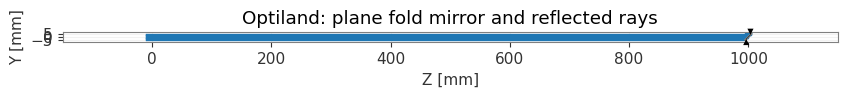

In [4]:
optiland_system.draw(num_rays=9)
plt.title('Optiland: plane fold mirror and reflected rays')
if CFG.save_figures:
    plt.gcf().savefig(FIG_DIR/'plane_mirror_optiland.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. xrt/raycing material and beamline

For an opaque mirror, xrt calculates the complex Fresnel amplitudes from the material tables and applies them to the ray coherency matrix. In constant mode, the custom material returns amplitudes `sqrt(R)`, so each ray carries intensity `R`.

In [5]:
class ConstantReflector(rmats.Material):
    def __init__(self, R):
        super().__init__(elements='Si', rho=2.33, kind='mirror', name='Constant-R mirror')
        self.R_user = float(R)

    def get_amplitude(self, E, beamInDotNormal, fromVacuum=True):
        shape = np.broadcast(np.asarray(E), np.asarray(beamInDotNormal)).shape
        amp = np.full(shape, np.sqrt(self.R_user) + 0j)
        mu = np.zeros(shape)
        return amp, amp.copy(), mu

def make_xrt_material(cfg: MirrorConfig):
    if cfg.reflectance_model == 'constant':
        return ConstantReflector(cfg.constant_reflectance)
    if ENERGY_EV < 30:
        raise ValueError(
            'xrt tabulated mirror mode is intended for EUV/X-ray energies. '
            "For visible/IR wavelengths set reflectance_model='constant'."
        )
    return rmats.Material(
        elements=cfg.mirror_formula, rho=cfg.mirror_density_g_cm3,
        kind='mirror', name=f'{cfg.mirror_formula} mirror'
    )

xrt_material = make_xrt_material(CFG)
theta = np.deg2rad(CFG.grazing_angle_deg)
rs0, rp0, *_ = xrt_material.get_amplitude(ENERGY_EV, np.sin(theta))
R_s0, R_p0 = float(np.abs(rs0)**2), float(np.abs(rp0)**2)
R_unpolarized = 0.5*(R_s0 + R_p0)
print(f'xrt material reflectance: Rs={R_s0:.6f}, Rp={R_p0:.6f}, mean={R_unpolarized:.6f}')

xrt material reflectance: Rs=0.682229, Rp=0.682204, mean=0.682217


In [6]:
def build_xrt_beamline(cfg: MirrorConfig, material):
    theta = np.deg2rad(cfg.grazing_angle_deg)
    two_theta = 2*theta
    E = HC_EV_NM/cfg.wavelength_nm
    # xrt 1.6.x does not accept the optional BeamLine name used by newer builds.
    bl = raycing.BeamLine(alignE=E)

    bl.source = rsources.GeometricSource(
        bl=bl, name='Geometric source', center=(0, 0, 0), nrays=cfg.n_rays,
        distx='flat', dx=cfg.source_width_mm,
        distz='flat', dz=cfg.source_height_mm,
        distxprime='normal', dxprime=cfg.divergence_x_mrad*1e-3,
        distzprime='normal', dzprime=cfg.divergence_z_mrad*1e-3,
        distE='lines', energies=(E,), polarization=cfg.polarization
    )
    bl.mirror = roes.OE(
        bl=bl, name='Finite plane mirror',
        center=(0, cfg.source_to_mirror_mm, 0), pitch=theta, material=material,
        limPhysX=[-cfg.mirror_half_width_mm, cfg.mirror_half_width_mm],
        limPhysY=[-cfg.mirror_half_length_mm, cfg.mirror_half_length_mm]
    )
    screen_center = (
        0.0,
        cfg.source_to_mirror_mm + cfg.mirror_to_screen_mm*np.cos(two_theta),
        cfg.mirror_to_screen_mm*np.sin(two_theta),
    )
    screen_z = (0.0, -np.sin(two_theta), np.cos(two_theta))
    bl.screen = rscreens.Screen(
        bl=bl, name='Reflected-beam screen', center=screen_center,
        x=(1.0, 0.0, 0.0), z=screen_z
    )
    return bl

def run_xrt_once(bl):
    source_beam = bl.source.shine()
    reflected_global, footprint_local = bl.mirror.reflect(source_beam)
    screen_local = bl.screen.expose(reflected_global)
    return source_beam, reflected_global, footprint_local, screen_local

beamline = build_xrt_beamline(CFG, xrt_material)
source_beam, reflected_beam, footprint, screen_beam = run_xrt_once(beamline)
good = np.asarray(screen_beam.state) > 0
print(f'Good rays at screen: {good.sum():,} / {CFG.n_rays:,} ({good.mean():.2%})')

Good rays at screen: 20,000 / 20,000 (100.00%)


## 4. Ray paths, screen footprint, and reflectance

The trajectory panel shows a subset of Monte-Carlo rays. The detector panel is coloured by per-ray intensity from the xrt coherency matrix.

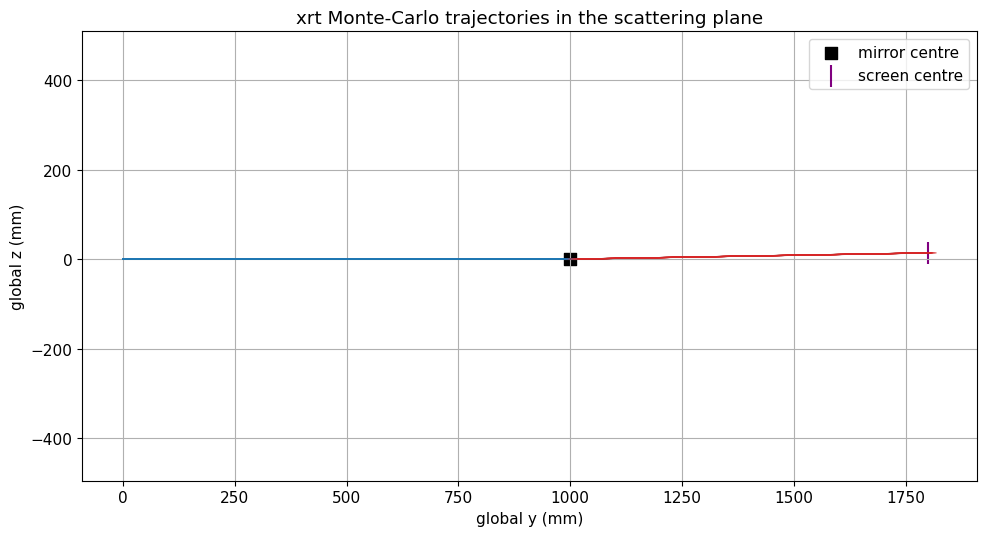

In [7]:
def ray_intensity(beam):
    return np.real(np.asarray(beam.Jss) + np.asarray(beam.Jpp))

sample = np.flatnonzero(np.asarray(reflected_beam.state) > 0)[:60]
L = CFG.mirror_to_screen_mm
fig, ax = plt.subplots(figsize=(10, 5.5))
for i in sample:
    ym, zm = reflected_beam.y[i], reflected_beam.z[i]
    ax.plot([0, ym], [source_beam.z[i], zm], color='tab:blue', alpha=0.20, lw=0.8)
    ax.plot([ym, ym + L*reflected_beam.b[i]],
            [zm, zm + L*reflected_beam.c[i]],
            color='tab:red', alpha=0.25, lw=0.8)
ax.scatter([CFG.source_to_mirror_mm], [0], marker='s', s=80, color='black', label='mirror centre')
ax.scatter([beamline.screen.center[1]], [beamline.screen.center[2]], marker='|', s=250, color='purple', label='screen centre')
ax.set(xlabel='global y (mm)', ylabel='global z (mm)', title='xrt Monte-Carlo trajectories in the scattering plane')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'plane_mirror_layout.png', dpi=180, bbox_inches='tight')
plt.show()

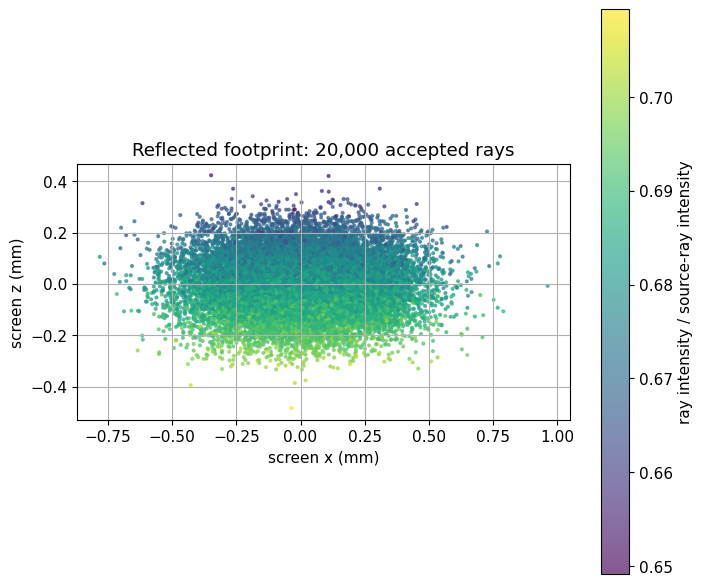

Screen RMS size: sigma_x=0.21379 mm, sigma_z=0.10645 mm


In [8]:
I = ray_intensity(screen_beam)
fig, ax = plt.subplots(figsize=(7.2, 6))
sc = ax.scatter(np.asarray(screen_beam.x)[good], np.asarray(screen_beam.z)[good],
                c=I[good], s=4, cmap='viridis', alpha=0.65, rasterized=True)
ax.set(xlabel='screen x (mm)', ylabel='screen z (mm)',
       title=f'Reflected footprint: {good.sum():,} accepted rays')
ax.set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=ax, label='ray intensity / source-ray intensity')
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'plane_mirror_screen.png', dpi=180, bbox_inches='tight')
plt.show()

if good.any():
    rms_x = np.std(np.asarray(screen_beam.x)[good])
    rms_z = np.std(np.asarray(screen_beam.z)[good])
    print(f'Screen RMS size: sigma_x={rms_x:.5f} mm, sigma_z={rms_z:.5f} mm')

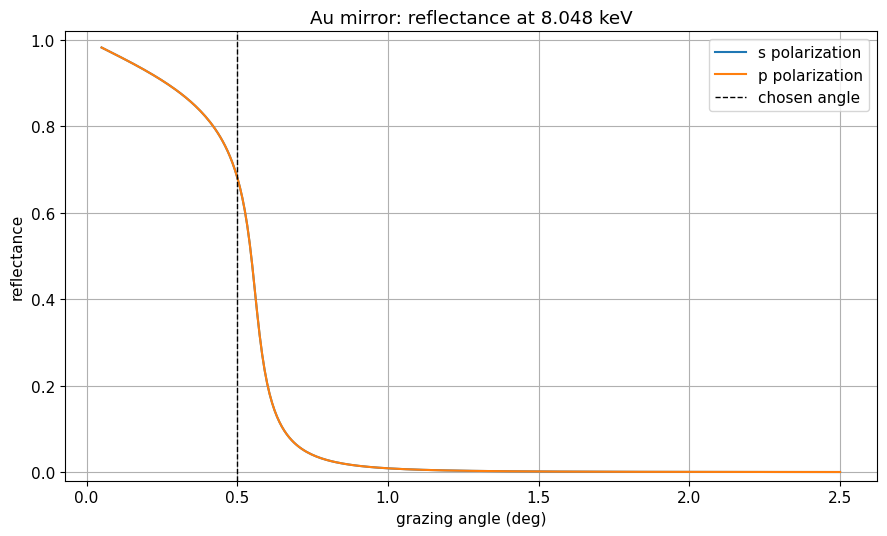

In [9]:
angles_deg = np.linspace(max(0.02, CFG.grazing_angle_deg/10),
                         min(10.0, max(2.5, 5*CFG.grazing_angle_deg)), 300)
rs, rp, *_ = xrt_material.get_amplitude(ENERGY_EV, np.sin(np.deg2rad(angles_deg)))
Rs, Rp = np.abs(rs)**2, np.abs(rp)**2
fig, ax = plt.subplots()
ax.plot(angles_deg, Rs, label='s polarization')
ax.plot(angles_deg, Rp, label='p polarization')
ax.axvline(CFG.grazing_angle_deg, color='k', ls='--', lw=1, label='chosen angle')
ax.set(xlabel='grazing angle (deg)', ylabel='reflectance', ylim=(-0.02, 1.02),
       title=f'{xrt_material.name}: reflectance at {ENERGY_EV/1000:.3f} keV')
ax.legend()
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'plane_mirror_reflectance.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Power budget and numerical checks

For a thick opaque mirror, `A = 1 - R`. In constant mode, `R`, `A`, and the residual transmission `T = 1-R-A` are independently editable subject to conservation. xrt traces the reflected branch; the table accounts for all branches.

,branch,fraction,power_for_1_W_input_W
0,reflected,0.682229,0.682229
1,absorbed,0.317771,0.317771
2,transmitted,0.000000,0.000000


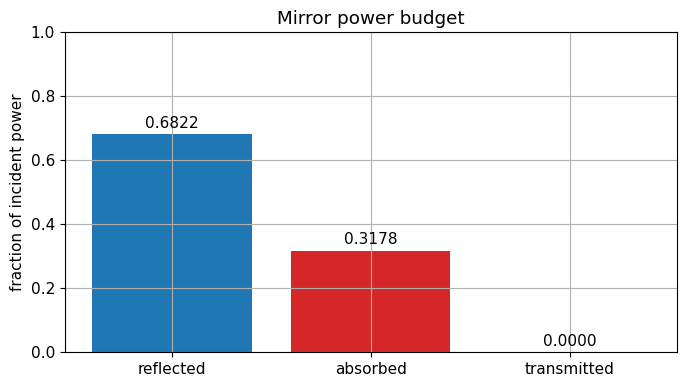

Mean xrt deflection = 0.999992 deg; expected = 1.000000 deg
All mirror invariants passed.


In [10]:
if CFG.reflectance_model == 'constant':
    R = CFG.constant_reflectance
    A = CFG.constant_absorptance
    T = 1.0 - R - A
else:
    if CFG.polarization.lower().startswith('h'):
        R = R_s0
    elif CFG.polarization.lower().startswith('v'):
        R = R_p0
    else:
        R = R_unpolarized
    A, T = 1.0 - R, 0.0

budget = pd.DataFrame({
    'branch': ['reflected', 'absorbed', 'transmitted'],
    'fraction': [R, A, T],
    'power_for_1_W_input_W': [R, A, T],
})
display(budget.style.format({'fraction': '{:.6f}', 'power_for_1_W_input_W': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(budget['branch'], budget['fraction'], color=['tab:blue', 'tab:red', 'tab:gray'])
ax.set(ylabel='fraction of incident power', ylim=(0, 1), title='Mirror power budget')
for j, val in enumerate(budget['fraction']):
    ax.text(j, val + 0.02, f'{val:.4f}', ha='center')
fig.tight_layout()
if CFG.save_figures:
    fig.savefig(FIG_DIR/'plane_mirror_energy_budget.png', dpi=180, bbox_inches='tight')
plt.show()

assert np.isclose(np.linalg.norm(expected_direction), 1.0, atol=1e-12)
assert np.isclose(R + A + T, 1.0, atol=1e-9)
mean_deflection = np.rad2deg(np.arctan2(np.mean(reflected_beam.c[good]),
                                         np.mean(reflected_beam.b[good])))
print(f'Mean xrt deflection = {mean_deflection:.6f} deg; expected = {2*CFG.grazing_angle_deg:.6f} deg')
assert np.isclose(mean_deflection, 2*CFG.grazing_angle_deg, atol=0.05)
print('All mirror invariants passed.')

## 6. What to vary

- Increase `grazing_angle_deg`: the outgoing beam rotates by twice that change; X-ray reflectance usually falls after the critical-angle region.
- Increase divergence or source size: the detector footprint broadens.
- Decrease mirror dimensions: more rays are rejected by the finite aperture.
- Change `mirror_formula` and density in `xrt_material` mode: the critical-angle and absorption behaviour change.
- For a measured visible-light coating, use constant mode and enter measured `R` and `A`.

The figures saved under `figures/` are consumed automatically by `ray_optics_simulation_report.tex`.